
# 🖊️ Federated Learning Lab: Quick Draw Sketch Recognition

**Group members:** _________________________ and _________________________

---

## What you will build

This lab walks you through four experiments, each answering one question:

| Experiment | Question |
|---|---|
| **Setup 1** | How well does a model trained *only on my data* generalise to my partner? |
| **Global model** | Does a larger, pre-trained model do better out of the box? |
| **Setup 2** | What happens when only one student joins federated learning? |
| **Setup 3** | What changes when both students join? |
| **Advanced** | What if someone poisons the data, or sends imbalanced classes? |

By the end, you will have participated in a real, live federated learning round
using the **Flower** framework — your notebook will actually connect to a server,
send weight updates, and receive a federated global model back.

---

### Classes (10)

```
cat   dog   sun   clock   mountain   tent   tree   bird   star   face
```

Three confusable pairs (`cat`/`dog`, `sun`/`clock`, `mountain`/`tent`) and
four high-variation classes (`tree`, `bird`, `star`, `face`) where two people
often draw the same thing very differently.


## ⚙️  Section 0 — Environment Setup

In [1]:
!pip install flwr scikit-learn matplotlib numpy Pillow ipywidgets ipycanvas nest-asyncio --quiet

In [2]:

import asyncio
import base64
import io
import os
import urllib.request
import warnings

import ipywidgets as widgets
import matplotlib.pyplot as plt
import nest_asyncio
import numpy as np
from IPython.display import display
from PIL import Image as PILImage
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    log_loss,
)

import flwr as fl

warnings.filterwarnings("ignore")
nest_asyncio.apply()          # lets async work inside Jupyter's event loop
np.random.seed(42)
plt.rcParams["figure.dpi"] = 100

print("All packages imported successfully.")


All packages imported successfully.


In [11]:
!pip install ipywidgets==7.7.1 ipycanvas==0.13.1 --quiet

In [4]:
import ipywidgets, ipycanvas
print(ipywidgets.__version__, ipycanvas.__version__)

7.7.1 0.13.1


In [3]:
from google.colab import output
output.enable_custom_widget_manager()


### 🔧 Your configuration

**Fill in your Student ID and the server address before running any other cells.**


In [38]:

# ── FILL THESE IN ─────────────────────────────────────────────────────────────
STUDENT_ID     = "A"                # "A"  or  "B"
SERVER_ADDRESS = "localhost:8090"   # Your instructor will give you the real IP
# ─────────────────────────────────────────────────────────────────────────────

CLASSES          = ["cat", "dog", "sun", "clock", "mountain",
                    "tent", "tree", "bird", "star", "face"]
N_CLASSES        = len(CLASSES)
N_FEATURES       = 784              # 28 × 28 pixels

SAMPLES_PER_CLASS = 200             # Quick Draw samples in your local slice
# Student A uses indices 0–199, Student B uses 200–399 — no overlap.
SLICE_START      = {"A": 0, "B": 200}[STUDENT_ID]

DATA_DIR         = "quickdraw_data"
MY_DRAWINGS_PATH = f"drawings_{STUDENT_ID}.npy"
PARTNER_ID       = "B" if STUDENT_ID == "A" else "A"
PARTNER_DRAWINGS = f"drawings_{PARTNER_ID}.npy"
SERVER_IP        = SERVER_ADDRESS.split(":")[0]
HTTP_PORT        = 8081             # file server on the instructor machine

print(f"Student      : {STUDENT_ID}")
print(f"Quick Draw   : slice [{SLICE_START}, {SLICE_START + SAMPLES_PER_CLASS})")
print(f"Partner      : Student {PARTNER_ID}")
print(f"FL server    : {SERVER_ADDRESS}")


Student      : A
Quick Draw   : slice [0, 200)
Partner      : Student B
FL server    : localhost:8090



---
## 📦 Section 1 — Load Quick Draw Data

Each student gets a **different, non-overlapping slice** of the Quick Draw dataset.
This simulates the real FL scenario: every client has their own local data.

| Student | Slice | Description |
|---|---|---|
| A | 0 – 199 | first 200 drawings per class |
| B | 200 – 399 | next 200 drawings per class |
| Instructor global model | 1 000 – 1 499 | completely separate from both |


In [5]:

BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"


def _download_class(cls: str) -> str:
    os.makedirs(DATA_DIR, exist_ok=True)
    path = os.path.join(DATA_DIR, f"{cls}.npy")
    if not os.path.exists(path):
        print(f"  Downloading {cls} ...", end=" ", flush=True)
        urllib.request.urlretrieve(f"{BASE_URL}{cls}.npy", path)
        print("✓")
    return path


def load_my_slice():
    X_list, y_list = [], []
    print(f"Loading Quick Draw slice for Student {STUDENT_ID} ...")
    for i, cls in enumerate(CLASSES):
        path = _download_class(cls)
        raw   = np.load(path, mmap_mode="r")
        chunk = raw[SLICE_START: SLICE_START + SAMPLES_PER_CLASS].copy()
        X_list.append(chunk)
        y_list.append(np.full(SAMPLES_PER_CLASS, i, dtype=np.int64))

    X = np.vstack(X_list).astype(np.float32) / 255.0
    y = np.concatenate(y_list)
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]


X_local, y_local = load_my_slice()

# 80 / 20 train / validation split
split     = int(0.8 * len(X_local))
X_train   = X_local[:split]
y_train   = y_local[:split]
X_val     = X_local[split:]
y_val     = y_local[split:]

print(f"\nTrain : {X_train.shape}")
print(f"Val   : {X_val.shape}")


Loading Quick Draw slice for Student A ...

Train : (1600, 784)
Val   : (400, 784)


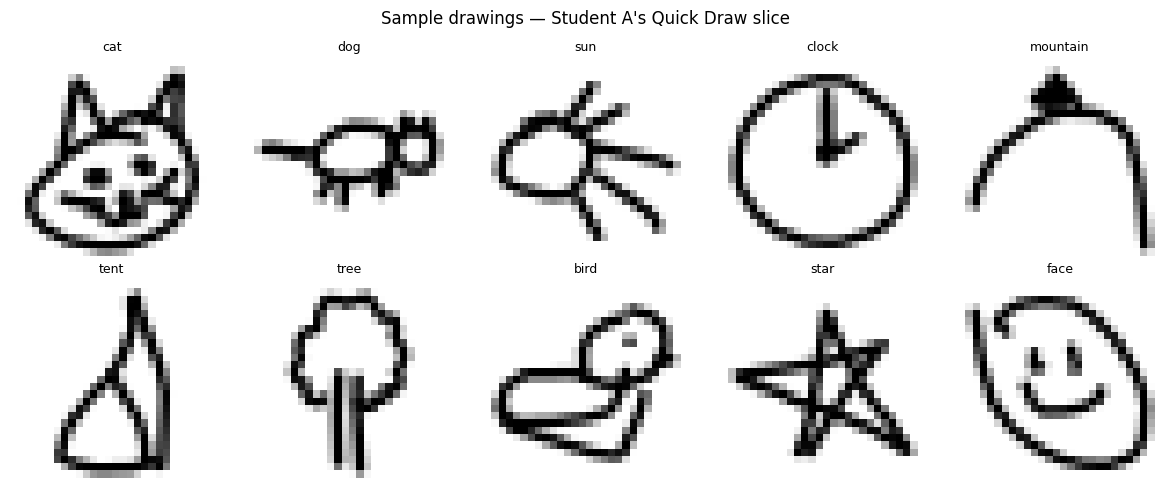

In [6]:

# Peek at a few samples from your slice
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle(f"Sample drawings — Student {STUDENT_ID}'s Quick Draw slice", fontsize=12)
for ax, cls, idx in zip(axes.flat, CLASSES, range(N_CLASSES)):
    sample_idx = np.where(y_train == idx)[0][0]
    ax.imshow(X_train[sample_idx].reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(cls, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()



---
## ✏️  Section 2 — Collect Your Personal Drawings

Draw **2 examples of each class** (20 drawings total).
These become your **personal test set** — we use them to evaluate every model.

**Why your own drawings matter:** Quick Draw was drawn by many different people
with many different styles. A model trained on that dataset has never seen *how
you specifically* draw a cat or a tree. Your personal drawings capture your
individual style, making them a fair test of real-world generalisation.

**Instructions:**
- Draw clearly and fill most of the canvas
- Click **Save ✓** after each drawing — you will see a tiny preview confirming it was captured
- After finishing all 20, run the *Compile* cell at the bottom of this section


In [7]:

from ipycanvas import Canvas

_sketch_data = {}   # {"{class}_{num}": np.ndarray(784,)}


class SketchWidget:
    """One drawing canvas for a single (class, drawing_number) pair."""

    def __init__(self, class_name: str, drawing_num: int):
        self.class_name  = class_name
        self.drawing_num = drawing_num
        self.key         = f"{class_name}_{drawing_num}"
        self._is_drawing = False

        # Canvas
        self.canvas = Canvas(width=280, height=280)
        self._reset_canvas()
        self.canvas.on_mouse_down(self._mouse_down)
        self.canvas.on_mouse_move(self._mouse_move)
        self.canvas.on_mouse_up(self._mouse_up)

        # Controls
        self.clear_btn  = widgets.Button(
            description="Clear", button_style="warning",
            layout=widgets.Layout(width="75px"),
        )
        self.save_btn   = widgets.Button(
            description="Save ✓", button_style="success",
            layout=widgets.Layout(width="75px"),
        )
        self.status_lbl = widgets.Label(value="not saved")
        self.preview    = widgets.Image(
            layout=widgets.Layout(width="56px", height="56px", border="1px solid #aaa"),
        )

        self.clear_btn.on_click(self._clear)
        self.save_btn.on_click(self._on_save_click)

        self.widget = widgets.VBox([
            widgets.Label(
                value=f"Draw: {class_name}  (#{drawing_num})",
                style={"font_weight": "bold"},
            ),
            self.canvas,
            widgets.HBox([self.clear_btn, self.save_btn,
                          self.status_lbl, self.preview]),
        ])

    # ── canvas helpers ────────────────────────────────────────────────────────
    def _reset_canvas(self):
        self.canvas.fill_style   = "white"
        self.canvas.fill_rect(0, 0, 280, 280)
        self.canvas.stroke_style = "black"
        self.canvas.line_width   = 8
        self.canvas.line_cap     = "round"
        self.canvas.line_join    = "round"

    def _mouse_down(self, x, y):
        self._is_drawing = True
        self.canvas.begin_path()
        self.canvas.move_to(x, y)

    def _mouse_move(self, x, y):
        if self._is_drawing:
            self.canvas.line_to(x, y)
            self.canvas.stroke()

    def _mouse_up(self, x, y):
        self._is_drawing = False

    def _clear(self, _btn):
        self.canvas.clear()
        self._reset_canvas()
        self.status_lbl.value = "cleared"

    # ── save ─────────────────────────────────────────────────────────────────
    def _on_save_click(self, _btn):
        self.status_lbl.value = "saving …"
        asyncio.ensure_future(self._async_save())

    async def _async_save(self):
        raw = await self.canvas.get_image_data()   # (280, 280, 4) RGBA uint8

        # Grayscale
        gray = (0.299 * raw[:, :, 0] +
                0.587 * raw[:, :, 1] +
                0.114 * raw[:, :, 2]).astype(np.uint8)

        # Resize 280 → 28
        img = PILImage.fromarray(gray, mode="L").resize((28, 28), PILImage.LANCZOS)
        arr = np.array(img, dtype=np.float32)

        # Invert — Quick Draw is white strokes on BLACK background
        arr = (255 - arr) / 255.0

        _sketch_data[self.key] = arr.flatten()

        # Tiny preview (show inverted so it looks natural)
        preview_arr = ((1 - arr.reshape(28, 28)) * 255).astype(np.uint8)
        buf = io.BytesIO()
        PILImage.fromarray(preview_arr, mode="L").save(buf, format="PNG")
        self.preview.value  = buf.getvalue()
        self.status_lbl.value = "✓ saved"

    def show(self):
        display(self.widget)


print("SketchWidget class ready.")


SketchWidget class ready.



### Drawing canvases

Each accordion panel contains **both drawings** for one class.
Open a class, draw, click Save ✓, then move to the next.


In [8]:

# Build one accordion panel per class, each containing two side-by-side canvases.
# Keep references so we can check _sketch_data later.
_widgets = {}

panels, titles = [], []
for cls in CLASSES:
    w1 = SketchWidget(cls, 1)
    w2 = SketchWidget(cls, 2)
    _widgets[f"{cls}_1"] = w1
    _widgets[f"{cls}_2"] = w2
    panels.append(widgets.HBox([w1.widget, w2.widget],
                                layout=widgets.Layout(gap="24px")))
    titles.append(cls)

accordion = widgets.Accordion(children=panels)
for i, t in enumerate(titles):
    accordion.set_title(i, t)
accordion.selected_index = None   # start collapsed

display(accordion)


Accordion(children=(HBox(children=(VBox(children=(Label(value='Draw: cat  (#1)'), Canvas(height=280, width=280…

In [13]:
from google.colab import output
import base64, io
import numpy as np
from PIL import Image as PILImage

_sketch_data = {}   # {"{class}_{num}": np.ndarray(784,)}

def _save_sketch_from_js(key, data_url):
    try:
        header, encoded = data_url.split(",", 1)
        img_bytes = base64.b64decode(encoded)
        raw_img = PILImage.open(io.BytesIO(img_bytes)).convert("RGBA")
        raw = np.array(raw_img)

        gray = (0.299 * raw[:, :, 0] +
                0.587 * raw[:, :, 1] +
                0.114 * raw[:, :, 2]).astype(np.uint8)

        img = PILImage.fromarray(gray, mode="L").resize((28, 28), PILImage.LANCZOS)
        arr = np.array(img, dtype=np.float32)
        arr = (255 - arr) / 255.0   # invert — Quick Draw is white strokes on black bg

        _sketch_data[key] = arr.flatten()
        return {"status": "ok", "key": key}
    except Exception as e:
        return {"status": "error", "message": str(e)}

output.register_callback('notebook.SaveSketch', _save_sketch_from_js)
print("Save callback registered.")

Save callback registered.


In [14]:
from IPython.display import HTML, display

CLASSES_LOCAL = CLASSES  # reuse your existing CLASSES list

html_parts = ["""
<style>
  .sketch-details { margin-bottom: 8px; border: 1px solid #ddd; border-radius: 6px; padding: 6px 10px; }
  .sketch-details summary { cursor: pointer; font-weight: bold; padding: 4px; }
  .sketch-row { display: flex; gap: 24px; margin-top: 8px; flex-wrap: wrap; }
  .sketch-box { text-align: center; }
  .sketch-canvas { border: 1px solid #888; touch-action: none; background: white; cursor: crosshair; }
  .sketch-controls { margin-top: 4px; display: flex; gap: 8px; align-items: center; justify-content: center; }
  .sketch-status { font-size: 12px; color: #555; min-width: 60px; }
  .sketch-btn { padding: 3px 10px; border-radius: 4px; border: none; cursor: pointer; font-size: 12px; color: white; }
  .clear-btn { background: #f0ad4e; }
  .save-btn { background: #5cb85c; }
</style>
"""]

for cls in CLASSES_LOCAL:
    html_parts.append(f'<details class="sketch-details"><summary>{cls}</summary><div class="sketch-row">')
    for num in [1, 2]:
        cid = f"{cls}_{num}"
        html_parts.append(f"""
        <div class="sketch-box">
          <div>{cls} (#{num})</div>
          <canvas id="{cid}" class="sketch-canvas" width="280" height="280"></canvas>
          <div class="sketch-controls">
            <button class="sketch-btn clear-btn" onclick="clearCanvas('{cid}')">Clear</button>
            <button class="sketch-btn save-btn" onclick="saveCanvas('{cid}', '{cid}')">Save ✓</button>
            <span class="sketch-status" id="{cid}_status">not saved</span>
          </div>
        </div>
        """)
    html_parts.append("</div></details>")

html_parts.append("""
<script>
function setupCanvas(id) {
  const canvas = document.getElementById(id);
  const ctx = canvas.getContext('2d');
  ctx.fillStyle = 'white';
  ctx.fillRect(0, 0, canvas.width, canvas.height);
  ctx.strokeStyle = 'black';
  ctx.lineWidth = 8;
  ctx.lineCap = 'round';
  ctx.lineJoin = 'round';
  let drawing = false;
  canvas.addEventListener('mousedown', e => { drawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); });
  canvas.addEventListener('mousemove', e => { if (drawing) { ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke(); } });
  window.addEventListener('mouseup', () => { drawing = false; });
}

function clearCanvas(id) {
  const canvas = document.getElementById(id);
  const ctx = canvas.getContext('2d');
  ctx.fillStyle = 'white';
  ctx.fillRect(0, 0, canvas.width, canvas.height);
  document.getElementById(id + '_status').innerText = 'cleared';
}

async function saveCanvas(id, key) {
  document.getElementById(id + '_status').innerText = 'saving …';
  const canvas = document.getElementById(id);
  const dataUrl = canvas.toDataURL('image/png');
  const result = await google.colab.kernel.invokeFunction('notebook.SaveSketch', [key, dataUrl], {});
  const status = result.data['application/json']['status'];
  document.getElementById(id + '_status').innerText = (status === 'ok') ? '✓ saved' : 'error';
}
</script>
""")

display(HTML("".join(html_parts)))

# Now actually wire up each canvas's drawing handlers
from IPython.display import Javascript
for cls in CLASSES_LOCAL:
    for num in [1, 2]:
        cid = f"{cls}_{num}"
        display(Javascript(f"setupCanvas('{cid}');"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Compile your personal test set

✓ Personal test set: (20, 784)  (20 drawings × 784 features)
  Saved to 'drawings_A.npy'

👉  Share this file with Student B.


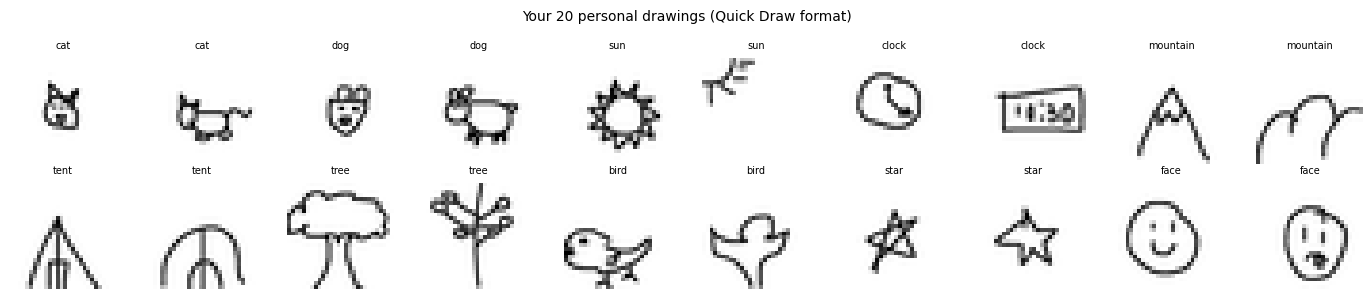

In [15]:

# Run this after finishing ALL 20 drawings.
missing = []
X_personal, y_personal = [], []

for i, cls in enumerate(CLASSES):
    for num in [1, 2]:
        key = f"{cls}_{num}"
        if key not in _sketch_data:
            missing.append(f"{cls} #{num}")
        else:
            X_personal.append(_sketch_data[key])
            y_personal.append(i)

if missing:
    print("⚠️  Still missing drawings:")
    for m in missing:
        print(f"   • {m}")
    print("Go back and save them before continuing.")
else:
    X_personal = np.array(X_personal, dtype=np.float32)
    y_personal = np.array(y_personal, dtype=np.int64)

    np.save(MY_DRAWINGS_PATH, {"X": X_personal, "y": y_personal},
            allow_pickle=True)

    print(f"✓ Personal test set: {X_personal.shape}  (20 drawings × 784 features)")
    print(f"  Saved to '{MY_DRAWINGS_PATH}'")
    print(f"\n👉  Share this file with Student {PARTNER_ID}.")

    # Quick visual check
    fig, axes = plt.subplots(2, 10, figsize=(14, 3))
    fig.suptitle(f"Your 20 personal drawings (Quick Draw format)", fontsize=10)
    for ax, vec, lbl in zip(axes.flat, X_personal, y_personal):
        ax.imshow(vec.reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
        ax.set_title(CLASSES[lbl], fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [21]:
import shutil

shutil.copy(MY_DRAWINGS_PATH, PARTNER_DRAWINGS)

'drawings_B.npy'

Next cell copies my drawings (person A) as person B's files for testing

In [24]:

# Load your partner's drawings (run after they share their file with you)
if os.path.exists(PARTNER_DRAWINGS):
    d = np.load(PARTNER_DRAWINGS, allow_pickle=True).item()
    X_partner = d["X"]
    y_partner = d["y"]
    print(f"✓ Partner drawings loaded: {X_partner.shape}")
else:
    X_partner, y_partner = None, None
    print(f"⚠️  '{PARTNER_DRAWINGS}' not found.")
    print(f"   Ask Student {PARTNER_ID} to share their file, then re-run this cell.")


✓ Partner drawings loaded: (20, 784)


---

In [25]:

# Shared evaluation helper — used throughout the rest of the notebook
def evaluate(model, X, y, title, ax=None):
    """Confusion matrix + accuracy for one model on one test set."""
    preds = model.predict(X)
    acc   = accuracy_score(y, preds)
    cm    = confusion_matrix(y, preds, labels=list(range(N_CLASSES)))

    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES).plot(
        ax=ax, colorbar=False, xticks_rotation=45
    )
    ax.set_title(f"{title}\nAcc: {acc:.1%}", fontsize=9)

    if created:
        plt.tight_layout()
        plt.show()

    return acc


def side_by_side(model, title_prefix):
    """Evaluate one model on own drawings and partner's drawings."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    acc_own = evaluate(model, X_personal, y_personal,
                       f"{title_prefix}\n→ Student {STUDENT_ID}'s drawings", axes[0])

    if X_partner is not None:
        acc_partner = evaluate(model, X_partner, y_partner,
                               f"{title_prefix}\n→ Student {PARTNER_ID}'s drawings", axes[1])
    else:
        axes[1].text(0.5, 0.5, f"Partner drawings\nnot yet loaded",
                     ha="center", va="center", transform=axes[1].transAxes, fontsize=11)
        axes[1].axis("off")
        acc_partner = None

    plt.tight_layout()
    plt.show()
    return acc_own, acc_partner



---
## 🧪 Section 3 — Setup 1: Local Model Only

Train a logistic regression model on **your own Quick Draw slice** and evaluate
it on both your drawings and your partner's drawings.

**Prediction:** The model sees only your 200-sample slice per class. It may do
reasonably on Quick Draw validation data, but will likely struggle on both sets
of personal drawings — especially your partner's, which it has never seen
anything like.


In [26]:

local_model = LogisticRegression(
    max_iter=1000, solver="lbfgs", multi_class="multinomial",
    C=1.0, random_state=42, n_jobs=-1,
)
local_model.fit(X_train, y_train)
print(f"Local model — Quick Draw val accuracy: {local_model.score(X_val, y_val):.1%}")


Local model — Quick Draw val accuracy: 58.5%


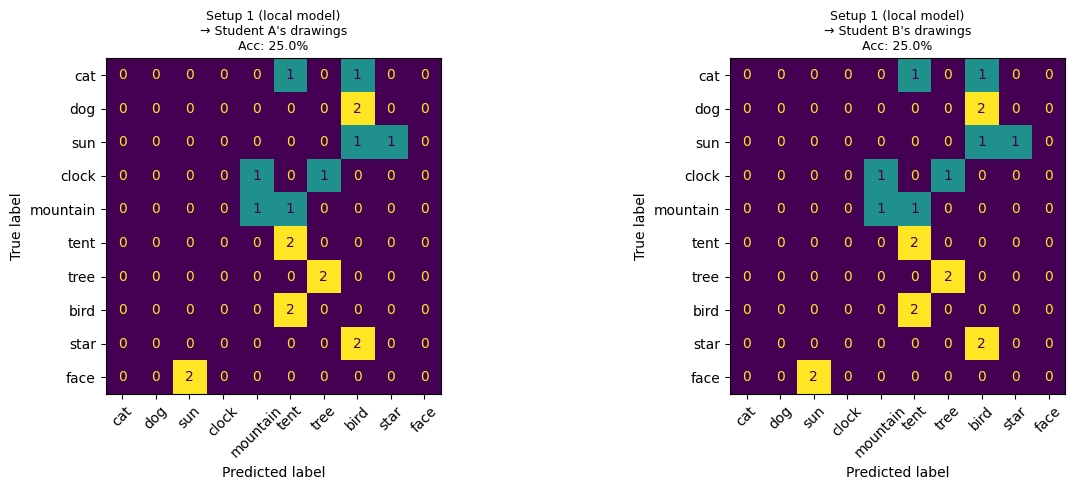


Setup 1 results:
  Student A's drawings : 25.0%
  Student B's drawings : 25.0%


In [27]:

acc_s1_own, acc_s1_partner = side_by_side(local_model, "Setup 1 (local model)")
print(f"\nSetup 1 results:")
print(f"  Student {STUDENT_ID}'s drawings : {acc_s1_own:.1%}")
if acc_s1_partner is not None:
    print(f"  Student {PARTNER_ID}'s drawings : {acc_s1_partner:.1%}")



> **Discussion**
> - Which class pairs are most confused?
> - Does the model perform equally on your drawings and your partner's?
> - Why do you think that is?


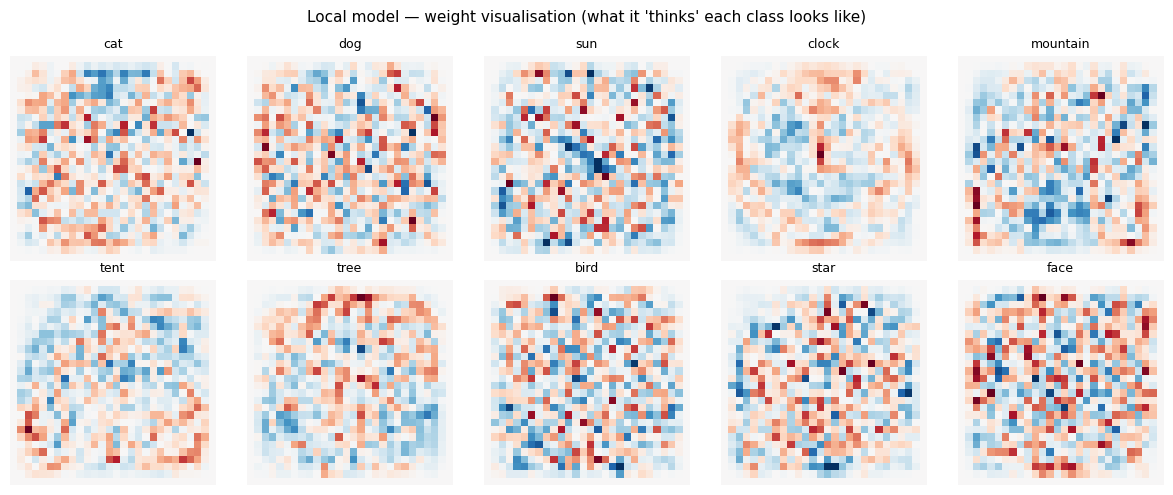

In [28]:

# Visualise the model's learned weights as 28×28 images — one per class.
# This shows what the model "thinks" each class looks like.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Local model — weight visualisation (what it 'thinks' each class looks like)",
             fontsize=11)
for ax, cls, coef_row in zip(axes.flat, CLASSES, local_model.coef_):
    img = coef_row.reshape(28, 28)
    ax.imshow(img, cmap="RdBu_r", vmin=-img.max(), vmax=img.max())
    ax.set_title(cls, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()



---
## 🌍 Section 4 — The Global Model

Your instructor pre-trained a logistic regression model on **500 samples/class**
from a completely separate slice of Quick Draw (indices 1000–1499 — no overlap
with your data). They are serving the weights file over HTTP.

**Prediction:** Because it saw more data from more diverse styles, it should
generalise better to personal drawings than your local model.


In [33]:

def download_from_server(filename: str) -> bool:
    url = f"http://{SERVER_IP}:{HTTP_PORT}/{filename}"
    print(f"Downloading {filename} from {url} ...", end=" ", flush=True)
    try:
        urllib.request.urlretrieve(url, filename)
        print("✓")
        return True
    except Exception as e:
        print(f"\n✗ Failed: {e}")
        print("  Ask your instructor to share the file manually.")
        return False


def load_weights(path: str) -> LogisticRegression:
    """Restore a LogisticRegression model from a saved .npy weight file."""
    w = np.load(path, allow_pickle=True).item()
    model = LogisticRegression(
        max_iter=100, warm_start=True, solver="lbfgs",
        multi_class="multinomial", C=1.0, n_jobs=-1,
    )
    # Initialise model structure with dummy data so sklearn creates coef_ / intercept_
    X_dummy = np.zeros((N_CLASSES * 2, N_FEATURES))
    y_dummy = np.repeat(np.arange(N_CLASSES), 2)
    model.fit(X_dummy, y_dummy)
    model.coef_      = w["coef"]
    model.intercept_ = w["intercept"]
    return model


download_from_server("global_model.npy")
global_model = load_weights("global_model.npy")
print(f"Global model — Quick Draw val accuracy: {global_model.score(X_val, y_val):.1%}")


Global model — Quick Draw val accuracy: 61.8%


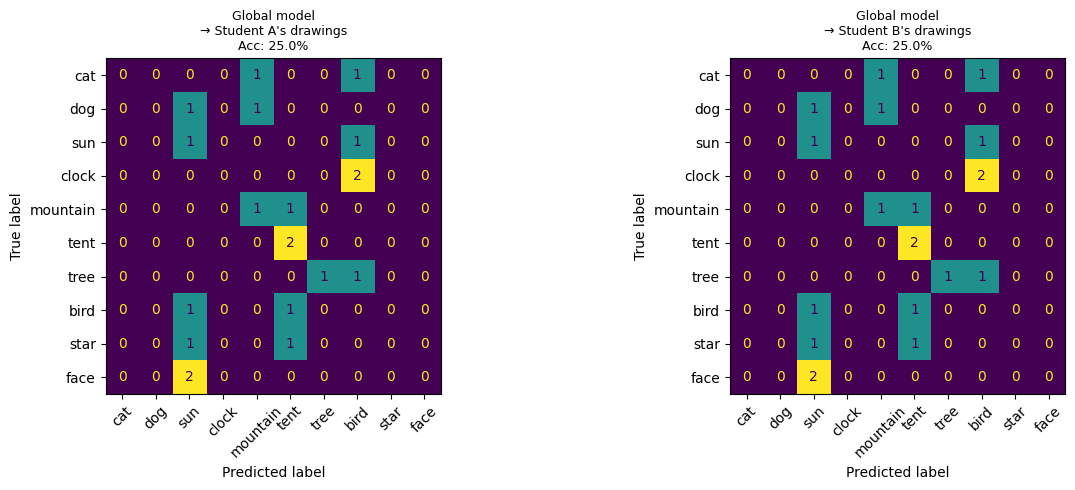


Global model results:
  Student A's drawings : 25.0%
  Student B's drawings : 25.0%


In [34]:

acc_global_own, acc_global_partner = side_by_side(global_model, "Global model")

print(f"\nGlobal model results:")
print(f"  Student {STUDENT_ID}'s drawings : {acc_global_own:.1%}")
if acc_global_partner is not None:
    print(f"  Student {PARTNER_ID}'s drawings : {acc_global_partner:.1%}")



> **Discussion**
> - Did the global model do better or worse than your local model on your own drawings?
> - What about on your partner's drawings?
> - Why might *more data* not always mean *better personalisation*?



---
## 🔗 Section 5 — Federated Learning with Flower

### How it works (in 30 seconds)

```
Server                            Client
──────                            ──────
Send global model weights   ──►   Receive weights
                                  Fine-tune on local Quick Draw slice
◄──  Return updated weights       (your data never leaves your machine)
Aggregate all clients (FedAvg)
Send aggregated model back  ──►   Evaluate
```

This repeats for N rounds. The server uses **FedAvg** — it averages the weight
matrices from all participating clients. Nobody's raw data is ever shared.

---

### The Flower client class


In [40]:

class SketchClient(fl.client.NumPyClient):
    """Flower NumPyClient wrapping a scikit-learn LogisticRegression."""

    def __init__(self, X_train, y_train, X_val, y_val):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val   = X_val
        self.y_val   = y_val

        # Initialise model structure (needs a first fit before coef_ exists)
        self.model = LogisticRegression(
            max_iter=100, warm_start=True, solver="lbfgs",
            multi_class="multinomial", C=1.0, n_jobs=-1,
        )
        X_dummy = np.zeros((N_CLASSES * 2, N_FEATURES))
        y_dummy = np.repeat(np.arange(N_CLASSES), 2)
        self.model.fit(X_dummy, y_dummy)

    # Called by Flower to push local weights up to the server
    def get_parameters(self, config):
        return [self.model.coef_, self.model.intercept_]

    # Called by Flower: server sends global weights → we fine-tune locally
    def fit(self, parameters, config):
        print("🔥 [fit] Received global parameters from server")
        self.model.coef_      = parameters[0]
        self.model.intercept_ = parameters[1]
        print("📥 [fit] Loaded global model into local model")

        print("🧠 [fit] Starting local training...")
        self.model.fit(self.X_train, self.y_train)
        print("✅ [fit] Finished training")
        val_acc = self.model.score(self.X_val, self.y_val)
        print(f"  [fit]  local val acc after fine-tuning: {val_acc:.1%}")
        return [self.model.coef_, self.model.intercept_], len(self.X_train), {}

    # Called by Flower: server sends aggregated weights → we evaluate
    def evaluate(self, parameters, config):
        self.model.coef_      = parameters[0]
        self.model.intercept_ = parameters[1]
        acc  = float(self.model.score(self.X_val, self.y_val))
        loss = float(log_loss(self.y_val, self.model.predict_proba(self.X_val)))
        print(f"  [eval] aggregated model val acc: {acc:.1%}")
        return loss, len(self.X_val), {"accuracy": acc}


print("SketchClient defined.")


SketchClient defined.



---
### Setup 2 — Only Student A Participates

**Student A:** Run the cell below. It will connect to the server and block until
all FL rounds finish.

**Student B:** Do NOT run the FL cell. Your instructor has set `--min-clients 1`
so the server only waits for one connection.

Both students evaluate the result afterward.


In [41]:

# ── STUDENT A ONLY — run this cell ───────────────────────────────────────────
print(f"Connecting to {SERVER_ADDRESS} ...")
print("The cell will block until all rounds complete. Please wait.")
print()

_client_s2 = SketchClient(X_train, y_train, X_val, y_val)
fl.client.start_numpy_client(server_address=SERVER_ADDRESS, client=_client_s2)

fl_model_s2 = _client_s2.model
print(f"\n✓ FL complete.  Final val acc: {fl_model_s2.score(X_val, y_val):.1%}")


Connecting to localhost:8090 ...
The cell will block until all rounds complete. Please wait.



	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode 

🔥 [fit] Received global parameters from server
📥 [fit] Loaded global model into local model
🧠 [fit] Starting local training...


INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: evaluate message a748aa48-29be-44e8-beaa-a1f62f9a62af
INFO:flwr:Received: evaluate message a748aa48-29be-44e8-beaa-a1f62f9a62af
INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: train message 8a1b414e-81f9-42ef-88e1-e6a50e39c409
INFO:flwr:Received: train message 8a1b414e-81f9-42ef-88e1-e6a50e39c409


✅ [fit] Finished training
  [fit]  local val acc after fine-tuning: 59.0%
  [eval] aggregated model val acc: 59.0%
🔥 [fit] Received global parameters from server
📥 [fit] Loaded global model into local model
🧠 [fit] Starting local training...


INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: evaluate message 9b6373ef-4f04-4526-95e3-07029dd979b1
INFO:flwr:Received: evaluate message 9b6373ef-4f04-4526-95e3-07029dd979b1
INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: train message 9a1edb1e-f24b-434b-b1e2-5aa363139637
INFO:flwr:Received: train message 9a1edb1e-f24b-434b-b1e2-5aa363139637


✅ [fit] Finished training
  [fit]  local val acc after fine-tuning: 58.5%
  [eval] aggregated model val acc: 58.5%
🔥 [fit] Received global parameters from server
📥 [fit] Loaded global model into local model
🧠 [fit] Starting local training...


INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: evaluate message 2d9d76c0-106f-4854-9891-945643278a96
INFO:flwr:Received: evaluate message 2d9d76c0-106f-4854-9891-945643278a96
INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: reconnect message bd21962c-b98c-41f0-a90b-5cecc33e8feb
INFO:flwr:Received: reconnect message bd21962c-b98c-41f0-a90b-5cecc33e8feb
DEBUG:flwr:gRPC channel closed
INFO :      Disconnect and shut down
INFO:flwr:Disconnect and shut down


✅ [fit] Finished training
  [fit]  local val acc after fine-tuning: 58.5%
  [eval] aggregated model val acc: 58.5%

✓ FL complete.  Final val acc: 58.5%


#### Both students: download and evaluate the Setup 2 model

In [42]:

# Both students run this cell.
# Adjust the round number if your instructor ran a different number of rounds.
FINAL_ROUND = 3

if download_from_server(f"aggregated_round_{FINAL_ROUND}.npy"):
    fl_model_s2 = load_weights(f"aggregated_round_{FINAL_ROUND}.npy")
    print(f"Setup 2 FL model  — val acc: {fl_model_s2.score(X_val, y_val):.1%}")


Setup 2 FL model  — val acc: 58.5%


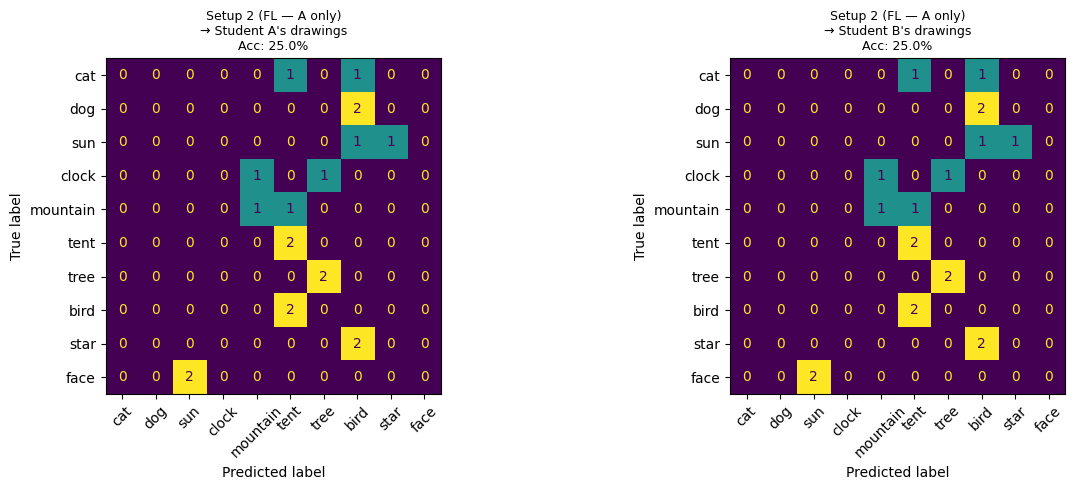


Setup 2 results:
  Student A's drawings : 25.0%
  Student B's drawings : 25.0%


In [43]:

acc_s2_own, acc_s2_partner = side_by_side(fl_model_s2, "Setup 2 (FL — A only)")

print(f"\nSetup 2 results:")
print(f"  Student {STUDENT_ID}'s drawings : {acc_s2_own:.1%}")
if acc_s2_partner is not None:
    print(f"  Student {PARTNER_ID}'s drawings : {acc_s2_partner:.1%}")



---
### Setup 3 — Both Students Participate

Your instructor restarts the server with `--min-clients 2`.

**Both students run the cell below at the same time.**
The server will only begin the FL round once *both* clients are connected.


In [44]:

# ── BOTH STUDENTS run this cell at the same time ──────────────────────────────
print(f"Connecting to {SERVER_ADDRESS} ...")
print("Waiting for your partner to connect before the round begins ...")
print()

_client_s3 = SketchClient(X_train, y_train, X_val, y_val)
fl.client.start_numpy_client(server_address=SERVER_ADDRESS, client=_client_s3)

fl_model_s3 = _client_s3.model
print(f"\n✓ FL complete.  Final val acc: {fl_model_s3.score(X_val, y_val):.1%}")


	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode 

Connecting to localhost:8090 ...
Waiting for your partner to connect before the round begins ...

🔥 [fit] Received global parameters from server
📥 [fit] Loaded global model into local model
🧠 [fit] Starting local training...


INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: evaluate message e68a0105-d21c-4122-924e-13eda3393939
INFO:flwr:Received: evaluate message e68a0105-d21c-4122-924e-13eda3393939
INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: train message 11d05b29-1685-4540-90be-56d38b53ae79
INFO:flwr:Received: train message 11d05b29-1685-4540-90be-56d38b53ae79


✅ [fit] Finished training
  [fit]  local val acc after fine-tuning: 59.0%
  [eval] aggregated model val acc: 59.0%
🔥 [fit] Received global parameters from server
📥 [fit] Loaded global model into local model
🧠 [fit] Starting local training...


INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: evaluate message 7447a60e-744b-49cc-9656-45bae239cd2c
INFO:flwr:Received: evaluate message 7447a60e-744b-49cc-9656-45bae239cd2c
INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: train message df88378e-9025-434c-958d-5259bb77b298
INFO:flwr:Received: train message df88378e-9025-434c-958d-5259bb77b298


✅ [fit] Finished training
  [fit]  local val acc after fine-tuning: 58.5%
  [eval] aggregated model val acc: 58.5%
🔥 [fit] Received global parameters from server
📥 [fit] Loaded global model into local model
🧠 [fit] Starting local training...


INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: evaluate message 0a47559d-fcc8-4b46-8402-52daa62a055e
INFO:flwr:Received: evaluate message 0a47559d-fcc8-4b46-8402-52daa62a055e
INFO :      Sent reply
INFO:flwr:Sent reply
INFO :      
INFO:flwr:
INFO :      Received: reconnect message 9968cfce-1432-4df6-9836-44888e1eb85b
INFO:flwr:Received: reconnect message 9968cfce-1432-4df6-9836-44888e1eb85b
DEBUG:flwr:gRPC channel closed
INFO :      Disconnect and shut down
INFO:flwr:Disconnect and shut down


✅ [fit] Finished training
  [fit]  local val acc after fine-tuning: 58.5%
  [eval] aggregated model val acc: 58.5%

✓ FL complete.  Final val acc: 58.5%


In [45]:

if download_from_server(f"aggregated_round_{FINAL_ROUND}.npy"):
    fl_model_s3 = load_weights(f"aggregated_round_{FINAL_ROUND}.npy")
    print(f"Setup 3 FL model  — val acc: {fl_model_s3.score(X_val, y_val):.1%}")


✗ Failed: <urlopen error [Errno 111] Connection refused>
  Ask your instructor to share the file manually.


In [ ]:

acc_s3_own, acc_s3_partner = side_by_side(fl_model_s3, "Setup 3 (FL — A + B)")

print(f"\nSetup 3 results:")
print(f"  Student {STUDENT_ID}'s drawings : {acc_s3_own:.1%}")
if acc_s3_partner is not None:
    print(f"  Student {PARTNER_ID}'s drawings : {acc_s3_partner:.1%}")



---
## 📊 Section 6 — All Setups Compared

Let's visualise all results together.


In [ ]:

setup_labels = [
    f"Setup 1\nLocal only",
    "Global\nmodel",
    "Setup 2\nFL: A only",
    "Setup 3\nFL: A + B",
]

accs_own     = [acc_s1_own,     acc_global_own,     acc_s2_own,     acc_s3_own]
accs_partner = [acc_s1_partner, acc_global_partner, acc_s2_partner, acc_s3_partner]

x     = np.arange(len(setup_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_own = ax.bar(x - width / 2,
                  [a if a is not None else 0 for a in accs_own],
                  width, label=f"Student {STUDENT_ID}'s drawings",
                  color="#3498db", alpha=0.85)
bars_ptn = ax.bar(x + width / 2,
                  [a if a is not None else 0 for a in accs_partner],
                  width, label=f"Student {PARTNER_ID}'s drawings",
                  color="#e74c3c", alpha=0.85)

for bar in list(bars_own) + list(bars_ptn):
    h = bar.get_height()
    ax.annotate(f"{h:.0%}",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(setup_labels, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy on personal drawings")
ax.set_title("Model Accuracy Across All Setups", fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend()
plt.tight_layout()
plt.show()

# Print table
print(f"{'Setup':<20} {'Own drawings':>14}  {'Partner drawings':>16}")
print("─" * 54)
rows = zip(setup_labels, accs_own, accs_partner)
for name, own, ptn in rows:
    own_s = f"{own:.1%}" if own is not None else "—"
    ptn_s = f"{ptn:.1%}" if ptn is not None else "—"
    print(f"{name.replace(chr(10), ' '):<20} {own_s:>14}  {ptn_s:>16}")



> **Discussion**
> - By how much did FL improve over the global model alone?
> - Adding Student B (Setup 3 vs 2): how much did the extra client help?
> - Which classes benefited most from federated learning?



---
## 🧨 Section 7 — Advanced Experiments

### Experiment A: Data Poisoning

What happens when one client deliberately **corrupts their labels**?

We simulate Student A mislabelling 80 % of their `cat` drawings as `dog`.
The poisoned weights get mixed into the global model via FedAvg.


In [ ]:

def poison_labels(y, source: str, target: str, fraction: float = 0.8) -> np.ndarray:
    """Flip `fraction` of source-class labels to target-class."""
    src, tgt = CLASSES.index(source), CLASSES.index(target)
    y_p      = y.copy()
    src_idx  = np.where(y_p == src)[0]
    n_flip   = int(len(src_idx) * fraction)
    y_p[src_idx[:n_flip]] = tgt
    print(f"Poisoned {n_flip}/{len(src_idx)} '{source}' labels → '{target}'")
    return y_p


y_train_poisoned = poison_labels(y_train, source="cat", target="dog", fraction=0.8)


In [ ]:

poisoned_model = LogisticRegression(
    max_iter=1000, solver="lbfgs", multi_class="multinomial",
    C=1.0, random_state=42, n_jobs=-1,
)
poisoned_model.fit(X_train, y_train_poisoned)


def per_class_accuracy(model, X, y) -> dict:
    preds = model.predict(X)
    return {CLASSES[i]: accuracy_score(y[y == i], preds[y == i])
            for i in range(N_CLASSES)}


clean_acc   = per_class_accuracy(local_model, X_val, y_val)
poison_acc  = per_class_accuracy(poisoned_model, X_val, y_val)

print(f"{'Class':<12}  {'Clean':>8}  {'Poisoned':>10}  {'Δ':>8}")
print("─" * 46)
for cls in CLASSES:
    delta = poison_acc[cls] - clean_acc[cls]
    flag  = "  ⚠️" if abs(delta) > 0.15 else ""
    print(f"{cls:<12}  {clean_acc[cls]:>8.1%}  {poison_acc[cls]:>10.1%}"
          f"  {delta:>+8.1%}{flag}")



> **Discussion**
> - Which classes are affected, and which are not? Why?
> - The poisoned client's *training* data was corrupted, but the *aggregated* model
>   is an average. Does averaging protect against poisoning?
> - What defences could the server apply to detect this?



---
### Experiment B: Class Imbalance

One client sends data that is **80 % cat and 20 % dog** for the cat/dog pair.
We simulate multiple FL rounds and watch how long it takes for the minority
class to recover.


In [ ]:

def make_imbalanced(X, y, dominant: str, dominant_frac: float = 0.8) -> tuple:
    """Keep all classes but skew the cat/dog balance."""
    dom_idx = CLASSES.index(dominant)
    min_idx = CLASSES.index("dog" if dominant == "cat" else "cat")

    other_mask = ~np.isin(y, [dom_idx, min_idx])
    X_other, y_other = X[other_mask], y[other_mask]

    dom_mask = (y == dom_idx)
    min_mask = (y == min_idx)

    n_dom = int(dominant_frac * SAMPLES_PER_CLASS)
    n_min = SAMPLES_PER_CLASS - n_dom

    X_imb = np.vstack([X_other, X[dom_mask][:n_dom], X[min_mask][:n_min]])
    y_imb = np.concatenate([y_other,
                             np.full(n_dom, dom_idx),
                             np.full(n_min, min_idx)])

    idx = np.random.permutation(len(X_imb))
    print(f"Imbalanced dataset:  {n_dom} '{dominant}',  {n_min} '{CLASSES[min_idx]}',  "
          f"{len(X_other)} other-class samples")
    return X_imb[idx], y_imb[idx]


X_imb, y_imb = make_imbalanced(X_train, y_train, dominant="cat", dominant_frac=0.8)


In [ ]:

def simulate_imbalanced_fl(X_imb, y_imb, n_rounds: int = 10) -> list:
    """Simulate n_rounds of FL where one client has imbalanced cat/dog data.
    Returns list of (cat_acc, dog_acc) per round.
    """
    global_w = np.load("global_model.npy", allow_pickle=True).item()
    coef      = global_w["coef"].copy()
    intercept = global_w["intercept"].copy()

    X_dummy = np.zeros((N_CLASSES * 2, N_FEATURES))
    y_dummy = np.repeat(np.arange(N_CLASSES), 2)
    cat_idx = CLASSES.index("cat")
    dog_idx = CLASSES.index("dog")
    history = []

    for r in range(1, n_rounds + 1):
        # Client fine-tunes from current global model on imbalanced data
        m = LogisticRegression(max_iter=100, warm_start=True,
                               solver="lbfgs", multi_class="multinomial", C=1.0)
        m.fit(X_dummy, y_dummy)
        m.coef_      = coef.copy()
        m.intercept_ = intercept.copy()
        m.fit(X_imb, y_imb)

        # FedAvg with just one client = client weights become new global
        coef      = m.coef_
        intercept = m.intercept_

        # Evaluate on validation set
        m_eval = LogisticRegression(max_iter=1, warm_start=True,
                                    solver="lbfgs", multi_class="multinomial")
        m_eval.fit(X_dummy, y_dummy)
        m_eval.coef_      = coef
        m_eval.intercept_ = intercept

        cat_acc = m_eval.score(X_val[y_val == cat_idx], y_val[y_val == cat_idx])
        dog_acc = m_eval.score(X_val[y_val == dog_idx], y_val[y_val == dog_idx])
        history.append((cat_acc, dog_acc))

    return history


history = simulate_imbalanced_fl(X_imb, y_imb, n_rounds=10)

# Reference: clean global model
gw = np.load("global_model.npy", allow_pickle=True).item()
cat_idx = CLASSES.index("cat")
dog_idx = CLASSES.index("dog")
ref_cat = global_model.score(X_val[y_val == cat_idx], y_val[y_val == cat_idx])
ref_dog = global_model.score(X_val[y_val == dog_idx], y_val[y_val == dog_idx])

rounds   = list(range(1, len(history) + 1))
cat_accs = [h[0] for h in history]
dog_accs = [h[1] for h in history]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rounds, cat_accs, "o-", color="#3498db", label="cat (dominant 80 %)")
ax.plot(rounds, dog_accs, "s-", color="#e74c3c", label="dog (minority 20 %)")
ax.axhline(ref_cat, color="#3498db", linestyle="--", alpha=0.5,
           label="global model cat (baseline)")
ax.axhline(ref_dog, color="#e74c3c", linestyle="--", alpha=0.5,
           label="global model dog (baseline)")
ax.set_xlabel("FL Round")
ax.set_ylabel("Accuracy")
ax.set_title("Class Imbalance: cat (80 %) vs dog (20 %) over FL Rounds")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nPer-round summary:")
print(f"{'Round':>6}  {'cat':>8}  {'dog':>8}")
print("─" * 28)
for r, (c, d) in enumerate(history, 1):
    print(f"{r:>6}  {c:>8.1%}  {d:>8.1%}")



> **Discussion**
> - How many rounds before dog accuracy drops noticeably?
> - Does cat accuracy improve at the expense of dog, or do both degrade?
> - If you were the server, what metric would you monitor to catch this?
> - How does this relate to fairness in real FL systems?



---
## 🎓 Lab Complete

### What you demonstrated

| Concept | How it showed up |
|---|---|
| **Distribution shift** | Local model struggled on partner's drawings |
| **Data scale** | Global model (500/class) beat local (200/class) |
| **Federated averaging** | Combined weights from both clients improved both evaluations |
| **Privacy** | Raw drawings never left your machine — only weight matrices were shared |
| **Data poisoning** | Corrupted labels degraded specific classes after FedAvg |
| **Class imbalance** | Dominant class crowded out the minority across FL rounds |

### Key takeaways
- More diverse participants in FL generally helps generalisation
- FedAvg is simple but fragile — it has no built-in defence against poisoning or imbalance
- The gap between *your data* and *everyone else's data* is exactly the problem FL solves
